In [189]:
import pandas as pd

df = pd.read_csv('../data/data.csv', sep=';')
df.columns = df.columns.str.strip()

In [190]:
df.shape

(4424, 37)

The dataset has 4,424 students (rows) and 37 columns: 36 features plus the Target outcome.

In [191]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Each row is one student. The columns cover background, family, money, and grades for semesters 1 and 2.

In [192]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

Every column is a number except Target, which is text. Categories like Course, Marital status, and parents' education are stored as number codes (for example, Course 9500 is one program), so they are labels, not amounts. I'll need to treat them as categories when modeling.

In [193]:
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Outcomes: 2,209 Graduate, 1,421 Dropout, 794 Enrolled.

In [194]:
df['Target'].value_counts(normalize=True).round(3)

Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

About 32% of students dropped out, 50% graduated, and 18% were still enrolled. The data is unbalanced: dropouts are about 1 in 3. So accuracy alone can be misleading. I should also check how many real dropouts the model catches (recall).

In [195]:
df.isna().sum().sum()

np.int64(0)

There are no missing values, so no cleaning is needed for blanks.

In [196]:
df['dropout'] = (df['Target'] == 'Dropout').astype(int)
df['dropout'].value_counts()

dropout
0    3003
1    1421
Name: count, dtype: int64

I made a new column, dropout: 1 = dropped out (1,421 students), 0 = did not (3,003 students, graduated or still enrolled). This is what the model will predict, like a real early warning tool.


# Why fairness matters

**1. What Wisconsin's system did**
Since 2012, Wisconsin has used a machine learning tool called the Dropout Early Warning System (DEWS) to predict whether middle schoolers will graduate from high school on time. Twice a year it labels 6th to 9th graders green, yellow, or red for risk. It uses test scores, attendance, discipline records, and how often a student changes schools. It also uses race, gender, and family income.

**2. What went wrong, and who it hurt**
The Markup (2023) found that the "high risk" label was usually wrong: about 74% of students it predicted would not graduate actually did. The false alarms were not spread evenly. The false alarm rate was 42 percentage points higher for Black students and 18 points higher for Hispanic students than for White students. So students of color were much more likely to be labeled "at risk" when they were fine. That label can lower how teachers see a student and how students see themselves. Most teachers didn't know race was part of the model, and a UC Berkeley study found no evidence that DEWS improved graduation rates. The tool added risk for students without clear benefit.

**3. How my project could make the same mistake**
My data has no race column, but it has other columns that can act the same way: age at enrollment, gender, scholarship status, debt, being international, and parents' education (first-generation). If my model leans on these, it could give more false alarms to older students, first-gen students, or students with money trouble, even when their grades are fine. It could also miss students in some groups more often. To avoid repeating Wisconsin's mistakes, I will:
- Check false alarm and miss rates for each group, not just overall accuracy.
- Choose the flagging cutoff based on the cost of mistakes, then recheck fairness at that cutoff.
- Explain each prediction with SHAP, so advisors can see why a student was flagged.
- Keep a human in the loop: the model suggests who to talk to, an advisor decides, and students are never told they are "high risk."

# Part 2: Who drops out? (SQL)
I loaded the data into a SQLite database and used SQL to compare dropout rates across groups.

In [197]:
import sqlite3

sql_df = df.rename(columns={
    'Target': 'target',
    'Tuition fees up to date': 'tuition_up_to_date',
    'Debtor': 'debtor',
    'Scholarship holder': 'scholarship',
    'Age at enrollment': 'age',
    'Gender': 'gender',
    'Curricular units 1st sem (approved)': 'sem1_passed',
})[['target', 'tuition_up_to_date', 'debtor', 'scholarship', 'age', 'gender', 'sem1_passed']]

conn = sqlite3.connect(':memory:')
sql_df.to_sql('students', conn, index=False)

def q(query):
    return pd.read_sql(query, conn)

q("SELECT COUNT(*) AS students FROM students")

,students
0,4424


In [198]:
q("""
SELECT tuition_up_to_date,
       COUNT(*) AS students,
       ROUND(100.0 * AVG(target = 'Dropout'), 1) AS dropout_pct
FROM students
GROUP BY tuition_up_to_date
""")

,tuition_up_to_date,students,dropout_pct
0,0,528,86.6
1,1,3896,24.7


Students with unpaid tuition dropped out at 86.6% vs. 24.7% for those who were paid up, about 3.5 times higher.

In [199]:
q("""
SELECT debtor,
       COUNT(*) AS students,
       ROUND(100.0 * AVG(target = 'Dropout'), 1) AS dropout_pct
FROM students
GROUP BY debtor
""")

,debtor,students,dropout_pct
0,0,3921,28.3
1,1,503,62.0


Students with debt dropped out at 62.0% vs. 28.3% for those who were debt free, about twice as high.

In [200]:
q("""
SELECT scholarship,
       COUNT(*) AS students,
       ROUND(100.0 * AVG(target = 'Dropout'), 1) AS dropout_pct
FROM students
GROUP BY scholarship
""")

,scholarship,students,dropout_pct
0,0,3325,38.7
1,1,1099,12.2


Students with scholarship dropped out at 12.2% vs. 38.7% for those who didn't get a scholarship, about 3 times less.

In [201]:
q("""
SELECT CASE
         WHEN age <= 20 THEN '17-20'
         WHEN age <= 24 THEN '21-24'
         WHEN age <= 34 THEN '25-34'
         ELSE '35+'
       END AS age_group,
       COUNT(*) AS students,
       ROUND(100.0 * AVG(target = 'Dropout'), 1) AS dropout_pct
FROM students
GROUP BY age_group
ORDER BY age_group
""")

,age_group,students,dropout_pct
0,17-20,2551,21.2
1,21-24,735,33.7
2,25-34,697,56.5
3,35+,441,53.7


Student in the age group 17-20 years old dropped out at 21.2%, students 21-24 years old dropped out at 33.7%, students 25-34 years old dropped out at 56.5%, while students aged 35+ dropped out at 53.7%. 
Dropout rises sharply with age: students who start at 25 or older drop out at over 50%, more than double the rate of students who start at 17 to 20 (21%).

In [202]:
q("""
SELECT CASE
         WHEN sem1_passed = 0 THEN '0 passed'
         WHEN sem1_passed <= 3 THEN '1-3 passed'
         WHEN sem1_passed <= 5 THEN '4-5 passed'
         ELSE '6+ passed'
       END AS sem1_group,
       COUNT(*) AS students,
       ROUND(100.0 * AVG(target = 'Dropout'), 1) AS dropout_pct
FROM students
GROUP BY sem1_group
ORDER BY sem1_group
""")

,sem1_group,students,dropout_pct
0,0 passed,718,79.4
1,1-3 passed,556,61.9
2,4-5 passed,1156,26.2
3,6+ passed,1994,10.2


Looking at grades and passing classes, when in semester 1, 79.4% of students that did not pass even 1 class dropped out, from students that passed 1-3 classes 61.9% dropped out, 26.2% of students who passed 4-5 classes dropped out, and from students who passed 6+ classes 10.2% dropped out. First-semester results are a strong warning sign: 79% of students who passed zero courses dropped out, vs. 10% of those who passed 6 or more, about 8 times higher

## Part 2 summary: Who drops out?

About 1 in 3 students (32%) dropped out overall, but the rate varies a lot by group.

| Factor | Higher-risk group | Lower-risk group | Gap |
|---|---|---|---|
| Tuition | Not up to date: 86.6% | Up to date: 24.7% | 3.5x |
| Debt | In debt: 62.0% | No debt: 28.3% | 2.2x |
| Scholarship | No scholarship: 38.7% | Scholarship: 12.2% | 3.2x |
| Age at enrollment | 25-34: 56.5%, 35+: 53.7% | 17-20: 21.2% | About 2.5x |
| Semester 1 courses passed | 0 passed: 79.4% | 6+ passed: 10.2% | About 8x |

**Key findings**
- **The strongest warning signs are unpaid tuition (87%) and passing zero courses in semester 1 (79%).**
- **Money matters:** unpaid tuition, debt, and no scholarship all raise dropout risk.
- **Grades matter:** the fewer courses a student passes in semester 1, the more likely they are to leave.
- This supports splitting at-risk students into three segments: **money trouble** (financial aid office), **grade trouble** (tutoring), and **both** (advisor meeting).

**Fairness note:** students who start at 25 or older drop out at over 50%. The model may learn to flag older students because of their age alone, even when their grades and finances are fine. I'll check false alarms by age group in the fairness step.

**Caution:** these are patterns, not causes. For example, a student who already plans to leave may stop paying tuition, so unpaid tuition could be a sign of dropping out rather than a reason for it.

# Part 3: Charts
Six charts showing who drops out. Each chart is saved to the charts/ folder.

In [203]:
import os
import matplotlib.pyplot as plt

os.makedirs('../charts', exist_ok=True)

BLUE = '#2a78d6'
GRAY = '#8a8984'
OVERALL = df['dropout'].mean() * 100

plt.rcParams.update({
    'figure.figsize': (7, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'left',
    'font.size': 11,
})

def rate_chart(rates, title, xlabel, filename):
    """Bar chart of dropout % per group, with the overall rate as a dashed line."""
    fig, ax = plt.subplots()
    bars = ax.bar(rates.index.astype(str), rates.values, color=BLUE, width=0.6)
    ax.bar_label(bars, fmt='%.0f%%', padding=3)
    ax.axhline(OVERALL, color=GRAY, linestyle='--', linewidth=1,
               label=f'All students: {OVERALL:.0f}%')
    ax.legend(frameon=False, loc='upper right')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Dropout rate (%)')
    ax.set_ylim(0, 100)
    fig.tight_layout()
    fig.savefig(f'../charts/{filename}', dpi=150)
    plt.show()

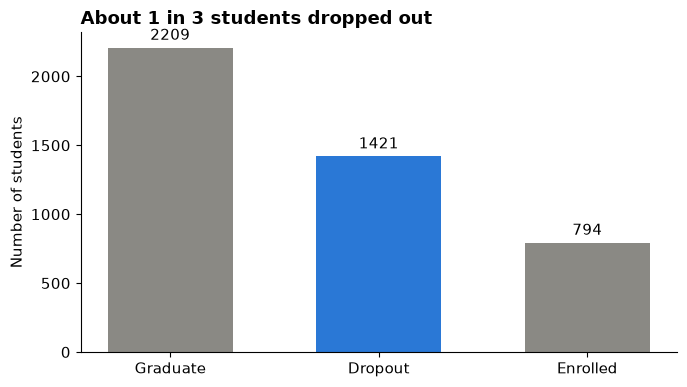

In [204]:
counts = df['Target'].value_counts()[['Graduate', 'Dropout', 'Enrolled']]
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values, color=[GRAY, BLUE, GRAY], width=0.6)
ax.bar_label(bars, padding=3)
ax.set_title('About 1 in 3 students dropped out')
ax.set_ylabel('Number of students')
fig.tight_layout()
fig.savefig('../charts/1_outcomes.png', dpi=150)
plt.show()

**Takeaway:** 1,421 of 4,424 students (32%) dropped out, about 1 in 3. That's a big group, but graduates still outnumber dropouts, so the data is unbalanced. A model could look accurate while missing many dropouts, so I'll track how many real dropouts it catches (recall), not just accuracy.

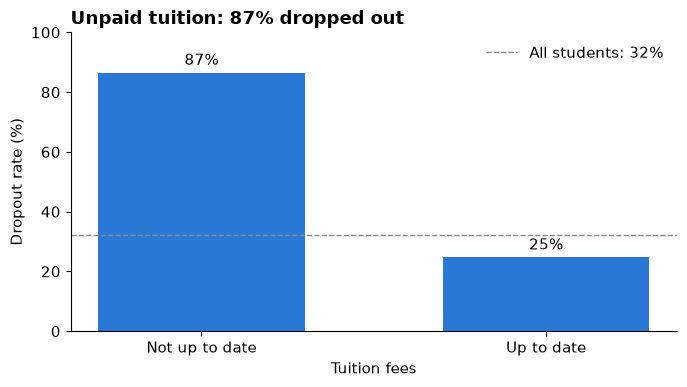

In [205]:
rates = df.groupby('Tuition fees up to date')['dropout'].mean() * 100
rates.index = rates.index.map({0: 'Not up to date', 1: 'Up to date'})
rate_chart(rates, 'Unpaid tuition: 87% dropped out', 'Tuition fees', '2_tuition.png')

**Takeaway:** Students with unpaid tuition dropped out at 87%, far above the 32% average. Students who were paid up were below average at 25%. Tuition status is the strongest money-related warning sign, though unpaid tuition may be a sign a student is already leaving, not just a cause.

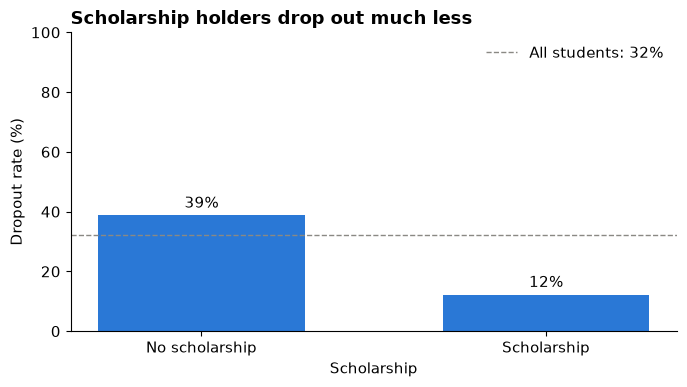

In [206]:
rates = df.groupby('Scholarship holder')['dropout'].mean() * 100
rates.index = rates.index.map({0: 'No scholarship', 1: 'Scholarship'})
rate_chart(rates, 'Scholarship holders drop out much less', 'Scholarship', '3_scholarship.png')

**Takeaway:** Scholarship holders dropped out at just 12%, far below the 32% average, while students without one were slightly above it at 39%. Financial support is linked to students staying, which points to the financial aid office as one form of outreach.

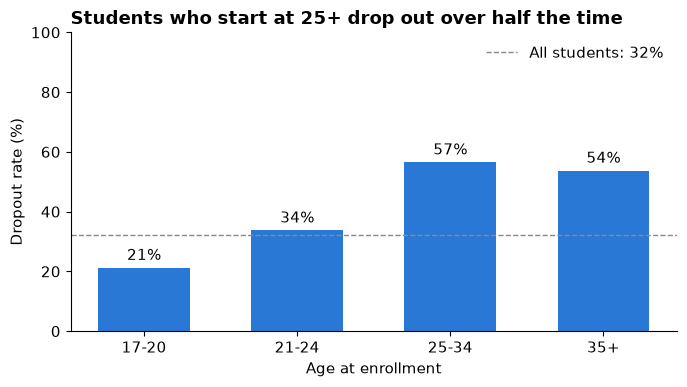

In [207]:
age_group = pd.cut(df['Age at enrollment'], bins=[0, 20, 24, 34, 100],
                   labels=['17-20', '21-24', '25-34', '35+'])
rates = df.groupby(age_group, observed=True)['dropout'].mean() * 100
rate_chart(rates, 'Students who start at 25+ drop out over half the time',
           'Age at enrollment', '4_age.png')

**Takeaway:** The big jump happens at age 25: dropout rises from 21% (ages 17-20) and 34% (21-24) to 57% (25-34) and 54% (35+). Older students may be balancing work, family, or money pressures. Fairness note: the model could over-flag older students, so I'll check false alarms by age group.

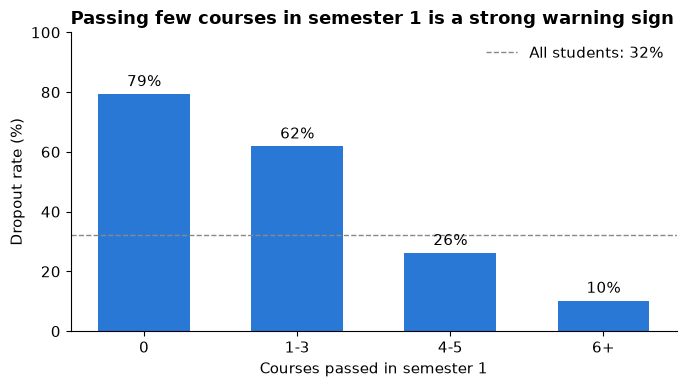

In [208]:
passed = pd.cut(df['Curricular units 1st sem (approved)'], bins=[-1, 0, 3, 5, 100],
                labels=['0', '1-3', '4-5', '6+'])
rates = df.groupby(passed, observed=True)['dropout'].mean() * 100
rate_chart(rates, 'Passing few courses in semester 1 is a strong warning sign',
           'Courses passed in semester 1', '5_sem1_passed.png')

**Takeaway:** Dropout falls steadily as students pass more courses: 79% for 0 passed, 62% for 1-3, 26% for 4-5, and 10% for 6+. Semester 1 results are one of the clearest warning signs, and they're available early enough for advisors to act.

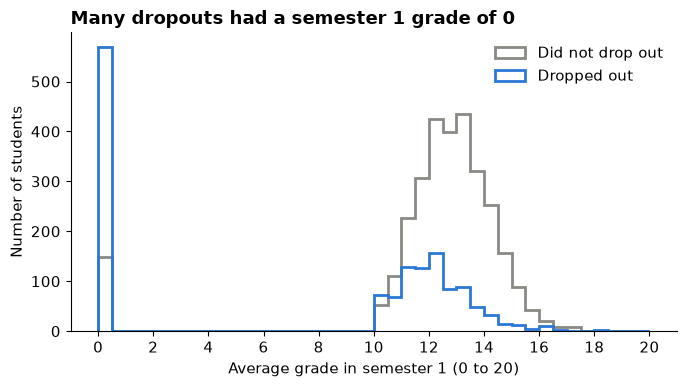

In [209]:
grade = 'Curricular units 1st sem (grade)'
fig, ax = plt.subplots()
ax.hist(df.loc[df['dropout'] == 0, grade], bins=40, range=(0, 20),
        histtype='step', linewidth=2, color=GRAY, label='Did not drop out')
ax.hist(df.loc[df['dropout'] == 1, grade], bins=40, range=(0, 20),
        histtype='step', linewidth=2, color=BLUE, label='Dropped out')
ax.set_xticks(range(0, 21, 2))
ax.set_title('Many dropouts had a semester 1 grade of 0')
ax.set_xlabel('Average grade in semester 1 (0 to 20)')
ax.set_ylabel('Number of students')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig('../charts/6_sem1_grade.png', dpi=150)
plt.show()

**Takeaway:** The tall spike at 0 shows 570 dropouts, 40% of all dropouts, with a semester 1 grade of 0. A 0 usually means no grades were recorded: about half of these students took no exams at all, so they may have stopped attending early. The dropouts who did get grades mostly scored 10-14, close to students who stayed (median 12.0 vs. 12.8). So grades alone don't explain every dropout. Some students pass their courses and still leave, likely for money or personal reasons.

## Part 3 summary
The strongest warning signs are early academic trouble (passing 0 courses or getting no grades in semester 1) and money trouble (unpaid tuition). The surprise was Chart 6: many dropouts had normal grades, so a grades-only model would miss them. That supports the three outreach segments: money trouble, grade trouble, and both.